In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sms
from datetime import datetime
plt.style.use('dark_background')

In [3]:
df = pd.read_csv(r"./Month_Value_1.csv")
df['Period'] = pd.to_datetime(df['Period'], format='%d.%m.%Y')
df.set_index('Period',inplace=True)
df.sort_index(inplace=True)
df.head()
df.dropna(inplace=True)

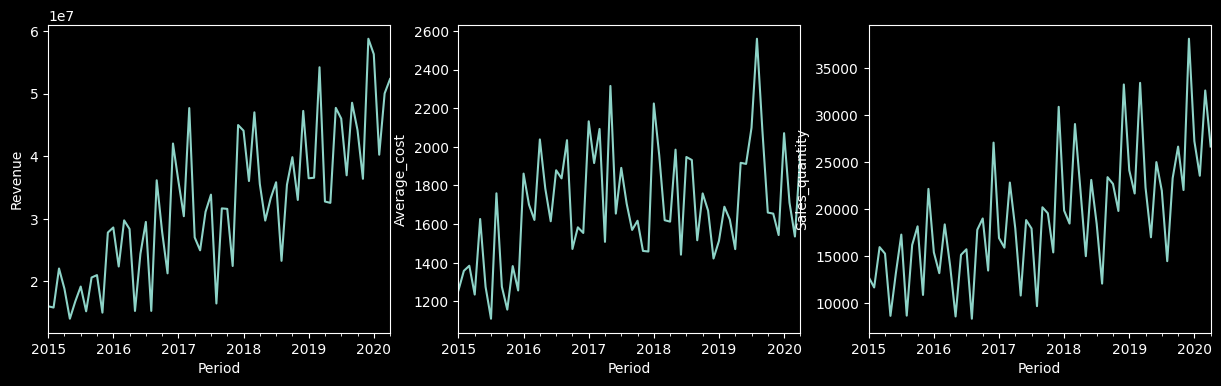

In [4]:
plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
df['Revenue'].plot()
plt.ylabel('Revenue')
plt.subplot(1,3,2)
df['Average_cost'].plot()
plt.ylabel('Average_cost')
plt.subplot(1,3,3)
df['Sales_quantity'].plot()
plt.ylabel('Sales_quantity')
plt.show()

In [5]:
print(df['Revenue'].corr(df['Sales_quantity']))
print(df['Average_cost'].corr(df['Sales_quantity']))
print(df['Revenue'].corr(df['Average_cost']))

0.8875703852660826
-0.09359855342344764
0.35827779036371765


In [6]:
df['Sales_cost_corr']= df['Sales_quantity'].rolling(12).corr(df['Average_cost'])

In [7]:
df[df['Sales_cost_corr']<-0.6]

,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region,Sales_cost_corr
Period,,,,,
2015-12-01,2.779181e+07,22113.0,1256.808558,30024676.0,-0.747905
2018-11-01,3.299915e+07,19765.0,1669.574764,28197847.0,-0.683477
2018-12-01,4.722183e+07,33207.0,1422.044394,28197847.0,-0.695081
2019-01-01,3.645996e+07,24096.0,1513.112554,29878525.0,-0.796039
2019-02-01,3.654650e+07,21624.0,1690.089653,29878525.0,-0.799502
2019-03-01,5.419871e+07,33379.0,1623.736682,29878525.0,-0.737905
2019-04-01,3.274399e+07,22265.0,1470.648534,29878525.0,-0.707521
2019-05-01,3.253166e+07,16967.0,1917.348827,29878525.0,-0.684716
2019-06-01,4.770970e+07,24958.0,1911.599553,29878525.0,-0.632310


In [8]:
df['Rev_cost_corr']= df['Revenue'].rolling(12).corr(df['Average_cost'])
df[df['Rev_cost_corr']<-0.4]

,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region,Sales_cost_corr,Rev_cost_corr
Period,,,,,,
2015-12-01,2.779181e+07,22113.0,1256.808558,30024676.0,-0.747905,-0.489845
2019-01-01,3.645996e+07,24096.0,1513.112554,29878525.0,-0.796039,-0.500442
2019-02-01,3.654650e+07,21624.0,1690.089653,29878525.0,-0.799502,-0.540444
2019-03-01,5.419871e+07,33379.0,1623.736682,29878525.0,-0.737905,-0.472875
2019-04-01,3.274399e+07,22265.0,1470.648534,29878525.0,-0.707521,-0.409676


<Axes: xlabel='Period'>

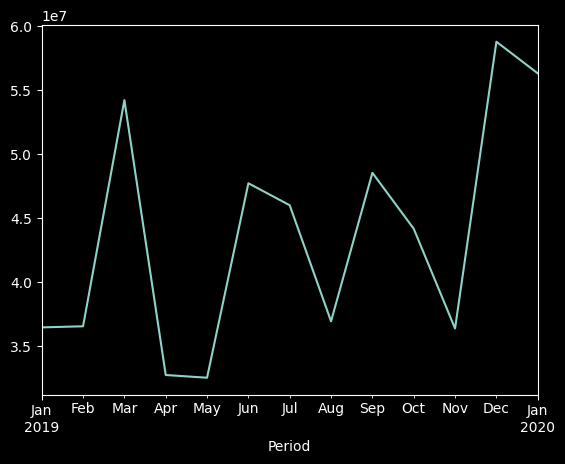

In [9]:
df[datetime(2019,1,1):datetime(2020,1,1)]['Revenue'].plot()

In [10]:
df['Month'] = df.index.month_name()
df['Revenue'].groupby(df['Month']).mean().sort_values()

Month
August       2.142642e+07
May          2.329324e+07
November     2.561718e+07
February     3.022724e+07
June         3.064834e+07
April        3.246345e+07
July         3.286318e+07
October      3.289444e+07
September    3.446896e+07
January      3.623914e+07
March        4.178012e+07
December     4.415008e+07
Name: Revenue, dtype: float64

In [11]:
df['Average_cost'].groupby(df['Month']).mean().sort_values()

Month
December     1447.012092
October      1533.146457
November     1550.380577
June         1579.631823
April        1638.600683
March        1646.446661
September    1696.844092
February     1721.890575
July         1785.255835
January      1843.213283
May          1925.817302
August       1958.513215
Name: Average_cost, dtype: float64

In [12]:
df['Sales_quantity'].groupby(df['Month']).std().sort_values()

Month
July         2297.291405
August       2584.919477
September    3227.225945
October      3481.074259
May          3815.286123
November     4562.059973
February     4686.675097
April        4828.605779
June         5034.506182
January      5475.103631
December     6058.178538
March        7410.050187
Name: Sales_quantity, dtype: float64

In [13]:
df['Sales_cost_corr'].groupby(df['Month']).mean()

Month
April       -0.471874
August      -0.464295
December    -0.556360
February    -0.508177
January     -0.499012
July        -0.413356
June        -0.458885
March       -0.462974
May         -0.438536
November    -0.531142
October     -0.445096
September   -0.445269
Name: Sales_cost_corr, dtype: float64

# Analysis
-Revenue = costs*sales_quantity
-Revenue is highly correlated with sales_quantity</br>
-August, May and November has least revenue generated</br>
    -August and May Reason maybe high cost so less sales, but Novemeber has medium sales but due to low costs, overall revenue is less </br>
-Highest sales is on December and March</br>
    -December product costs were less, maybe christmas sales, and march product costs were moderate but sales high, maybe Spring Sales</br>
-There is no good negative coorelation between Cost and sales quantity, which is prob due to festive seasons and necessity materials</br>
-October has good sales, prob festive season or Halloween month and January good sales even tho prices high
-Over the years, Prices in December and November haven't increased much


In [14]:
df = pd.read_csv(r"./Month_Value_1.csv")
df['Period'] = pd.to_datetime(df['Period'], format='%d.%m.%Y')
df.set_index('Period',inplace=True,drop=False)
df.sort_index()
df.head()

,Period,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
Period,,,,,
2015-01-01,2015-01-01,1.601007e+07,12729.0,1257.763541,30024676.0
2015-02-01,2015-02-01,1.580759e+07,11636.0,1358.507000,30024676.0
2015-03-01,2015-03-01,2.204715e+07,15922.0,1384.697024,30024676.0
2015-04-01,2015-04-01,1.881458e+07,15227.0,1235.606705,30024676.0
2015-05-01,2015-05-01,1.402148e+07,8620.0,1626.621765,30024676.0


In [15]:
df.dropna(inplace=True)

In [16]:
df

,Period,Revenue,Sales_quantity,Average_cost,The_average_annual_payroll_of_the_region
Period,,,,,
2015-01-01,2015-01-01,1.601007e+07,12729.0,1257.763541,30024676.0
2015-02-01,2015-02-01,1.580759e+07,11636.0,1358.507000,30024676.0
2015-03-01,2015-03-01,2.204715e+07,15922.0,1384.697024,30024676.0
2015-04-01,2015-04-01,1.881458e+07,15227.0,1235.606705,30024676.0
2015-05-01,2015-05-01,1.402148e+07,8620.0,1626.621765,30024676.0
...,...,...,...,...,...
2019-12-01,2019-12-01,5.875647e+07,38069.0,1543.420464,29878525.0
2020-01-01,2020-01-01,5.628830e+07,27184.0,2070.640850,29044998.0
2020-02-01,2020-02-01,4.022524e+07,23509.0,1711.057181,29044998.0


In [17]:
from statsmodels.tsa.stattools import adfuller
def check(x):
    r = adfuller(x)
    print(r[1]<0.05)
check(df['Revenue'])
check(df['Sales_quantity'])

False
False


In [18]:
df['R_1']=df['Revenue']-df['Revenue'].shift(1)
df['R_12']=df['Revenue']-df['Revenue'].shift(12)
df['R_12_1']= df['R_12'] - df['R_12'].shift(1)
check(df['R_1'].dropna())
check(df['R_12'].dropna())
check(df['R_12_1'].dropna())
df['R_s'] = df['R_12_1'] - df['R_12_1'].shift(1)
check(df['R_s'].dropna())

True
False
False
True


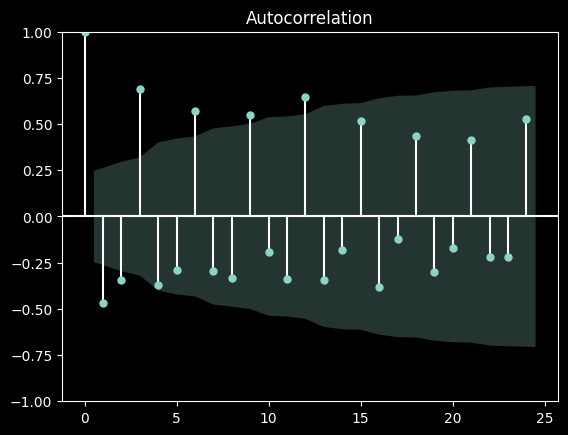

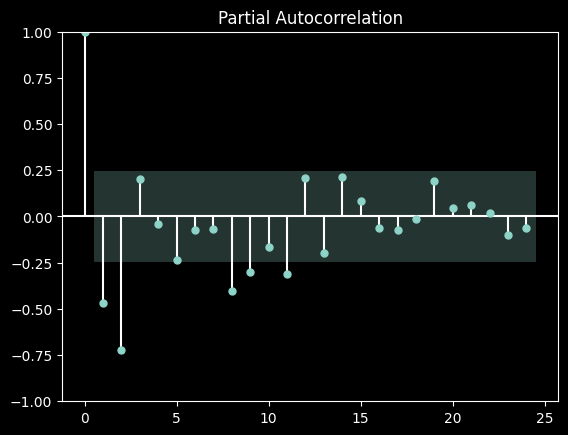

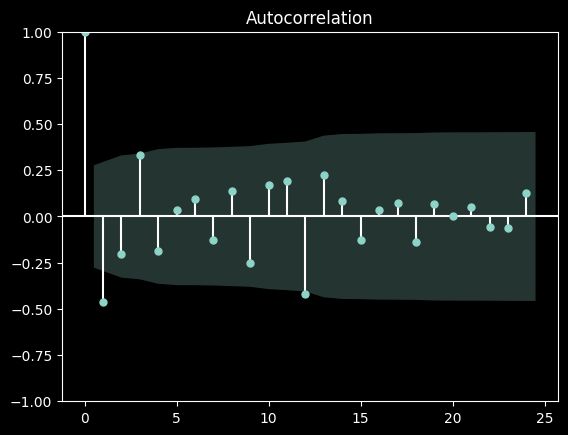

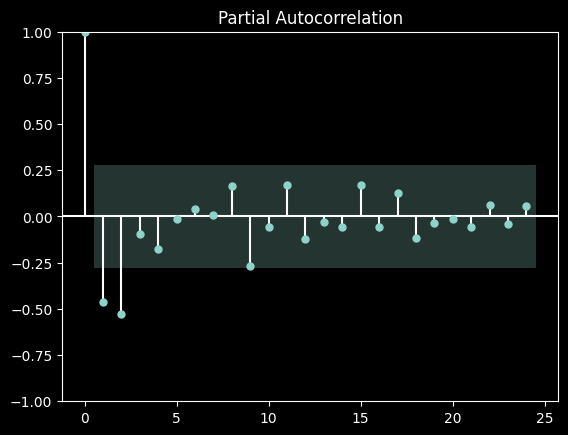

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
acf = plot_acf(df['R_1'].dropna(),lags=24)
pacf = plot_pacf(df['R_1'].dropna(),lags=24)
acf = plot_acf(df['R_s'].dropna(),lags=24)
pacf = plot_pacf(df['R_s'].dropna(),lags=24)

In [20]:
from datetime import  timedelta
stop = datetime(2018,12,1)
train = df[:stop].copy()
test = df[stop+timedelta(1):].copy()

In [21]:
from darts.models import ARIMA, ExponentialSmoothing
from darts import TimeSeries
from darts.metrics import rmse
series = TimeSeries.from_dataframe(train, 'Period', 'Revenue',freq='MS')
t_series = TimeSeries.from_dataframe(test, 'Period', 'Revenue',freq='MS')
model = ARIMA(p=2,q=1,d=1, seasonal_order=(2,2,1,12)).fit(series)
es = ExponentialSmoothing().fit(series)
forecast = model.predict(len(test))
es_fc = es.predict(len(test))
forecast_df = forecast.pd_dataframe()
es_df = es_fc.pd_dataframe()
print(rmse(forecast,t_series))
print(rmse(es_fc,t_series))
print("error %age-",rmse(es_fc,t_series)/test['Revenue'].mean())


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


8414068.082028199
5254407.253903945
error %age- 0.1184440719051496


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


<Axes: xlabel='Period'>

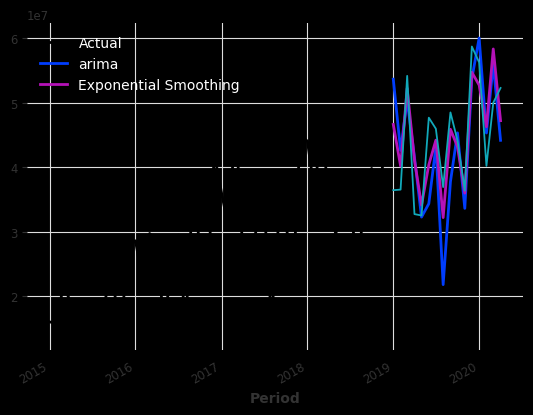

In [22]:
series.plot(label="Actual")
forecast.plot(label="arima")
es_fc.plot(label="Exponential Smoothing")
test['Revenue'].plot()

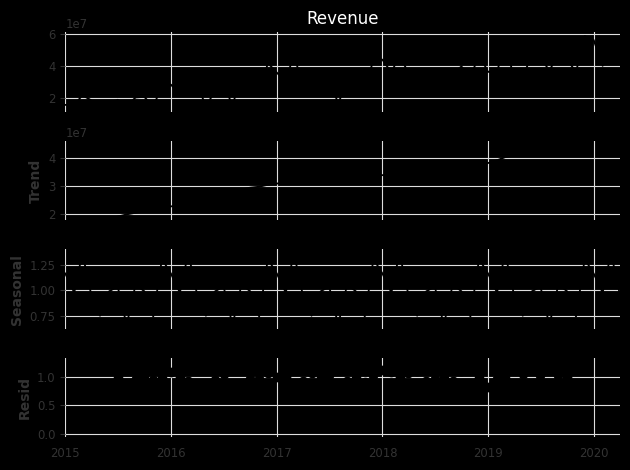

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
r = seasonal_decompose(df['Revenue'],period=12, model='multiplicative')
r.plot()
plt.show()

In [24]:
df['Trend'] = r.trend
df['Seas'] = r.seasonal
df['Resid'] = r.resid
df['T1'] = df['Trend'] - df['Trend'].shift(1)
df['T2'] = df['T1'] - df['T1'].shift(1)
df['T3'] = df['T2'] - df['T2'].shift(1)
check(df['T3'].dropna())
stop = datetime(2018,12,1)
train = df[:stop].copy()
test = df[stop+timedelta(1):].copy()

True


<Axes: xlabel='Period'>

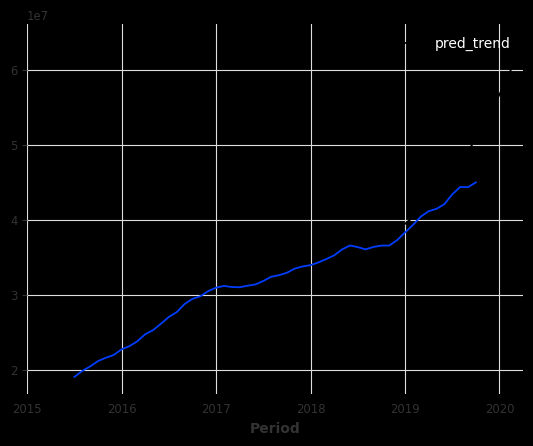

In [25]:
from numpy.polynomial.polynomial import Polynomial
x = np.arange(len(train.dropna()))
p = Polynomial.fit(x, train.dropna()['Revenue'],deg=3)
pred = p(np.arange(len(train.dropna()),len(train.dropna())+len(test)))
test['pred_trend'] = pred
test[['pred_trend']].plot()
df['Trend'].plot()

In [26]:
check(df['Resid'].dropna())

True


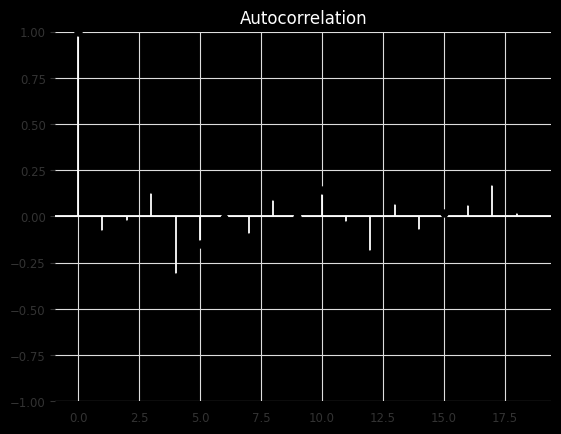

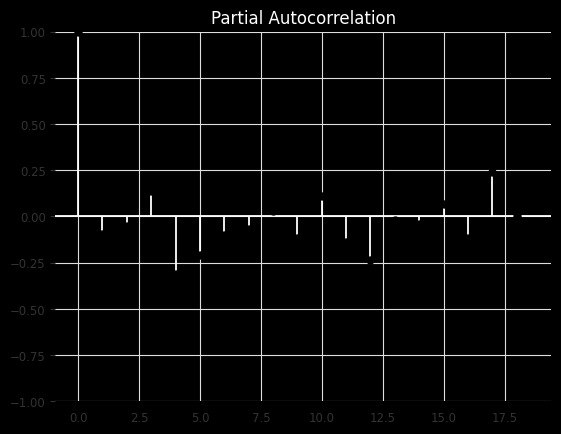

In [27]:
acf = plot_acf(df['Resid'].dropna())
pacf = plot_pacf(df['Resid'].dropna())

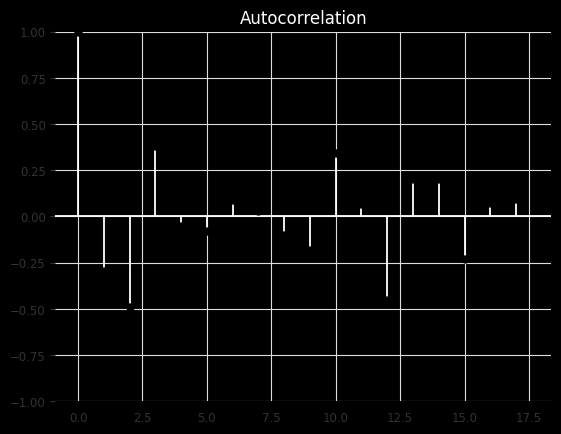

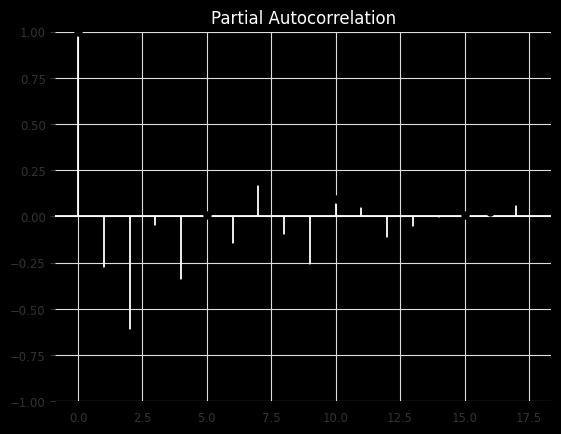

In [28]:
acf = plot_acf(df['T3'].dropna())
pacf = plot_pacf(df['T3'].dropna())

In [29]:
from statsmodels.stats.diagnostic import acorr_ljungbox
result = acorr_ljungbox(df['T3'].dropna(), lags=10, return_df=True)
print(result)

      lb_stat  lb_pvalue
1    4.454349   0.034812
2   17.153381   0.000188
3   24.993400   0.000015
4   25.150439   0.000047
5   25.518134   0.000111
6   25.987954   0.000224
7   26.040407   0.000495
8   26.633791   0.000818
9   28.647089   0.000743
10  36.108509   0.000081


In [30]:
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(train['T3'].dropna(), lags=9).fit()
print(model.summary())
pred = model.forecast(steps=len(test))

                            AutoReg Model Results                             
Dep. Variable:                     T3   No. Observations:                   39
Model:                     AutoReg(9)   Log Likelihood                -410.516
Method:               Conditional MLE   S.D. of innovations         212122.993
Date:                Sun, 05 Jan 2025   AIC                            843.032
Time:                        00:11:52   BIC                            858.445
Sample:                    07-01-2016   HQIC                           847.962
                         - 12-01-2018                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2295.7133   3.94e+04     -0.058      0.954   -7.96e+04     7.5e+04
T3.L1         -0.5943      0.169     -3.509      0.000      -0.926      -0.262
T3.L2         -1.2489      0.197     -6.333      0.0

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


<Axes: xlabel='Period'>

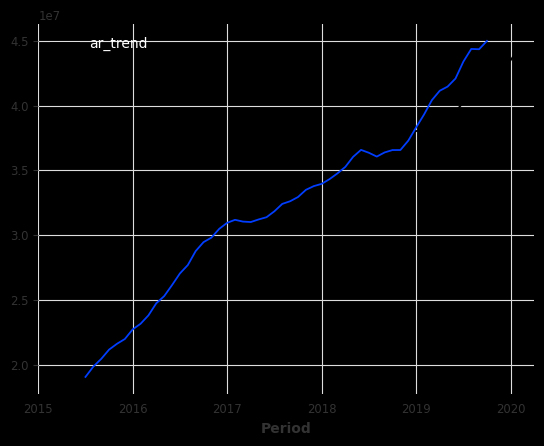

In [31]:
t2_pred = np.cumsum(np.concatenate([[train['T2'].iloc[-1]],pred]))
t1_pred = np.cumsum(np.concatenate([[train['T1'].iloc[-1]],t2_pred[1:]]))
t_pred = np.cumsum(np.concatenate([[train['Trend'].iloc[-1]],t1_pred[1:]]))
test['ar_trend'] = t_pred[1:]
test[['ar_trend']].plot()
df['Trend'].plot()


In [32]:
from statsmodels.stats.diagnostic import acorr_ljungbox
result = acorr_ljungbox(df['Resid'].dropna(), lags=10, return_df=True)
print(result)

      lb_stat  lb_pvalue
1    0.498360   0.480222
2    0.597977   0.741568
3    1.845343   0.605118
4    8.085022   0.088513
5    9.365324   0.095350
6    9.371769   0.153724
7   10.161358   0.179612
8   10.947392   0.204698
9   10.948125   0.279282
10  12.333286   0.263370


resid is random so can't use ar model

rmse error:  8367170.850771117
mape:  0.16079190674862645


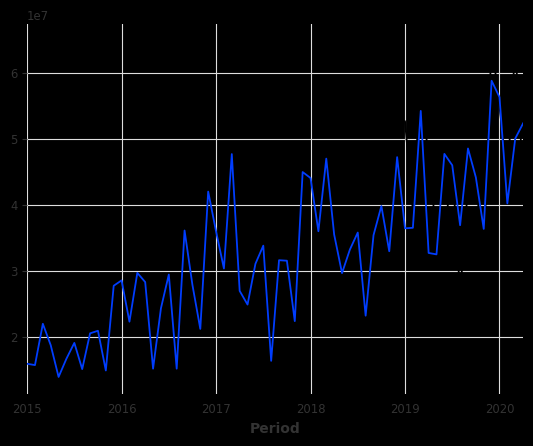

In [33]:
mean_residual = df['Resid'].mean()
std_residual = df['Resid'].std()
pred_res = np.random.normal(loc=mean_residual, scale=std_residual, size=len(test))
#pred_res = np.random.uniform(low=0.77, high=1.26, size=len(test))
#pred_res = np.random.choice(train['Resid'].dropna(), size=len(test), replace=True)
test['pred_res'] = pred_res
test['ar_rev'] =test['ar_trend']*test['Seas']*test['pred_res']
test['ar_rev'].plot()
df['Revenue'].plot()
from sklearn.metrics import root_mean_squared_error as rmse, mean_absolute_percentage_error as mape
print("rmse error: ", rmse(test['Revenue'],test['ar_rev']))
print("mape: ", mape(test['Revenue'],test['ar_rev']))

In [34]:
df = pd.DataFrame({'Period': df['Period'], 'Revenue': df['Revenue']})
df_tsfresh = df.reset_index(drop=True)
df_tsfresh['ID'] = 1
df_tsfresh.rename(columns={'Period': 'Time', 'Revenue': 'Value'}, inplace=True)
print(df_tsfresh.head())


        Time         Value  ID
0 2015-01-01  1.601007e+07   1
1 2015-02-01  1.580759e+07   1
2 2015-03-01  2.204715e+07   1
3 2015-04-01  1.881458e+07   1
4 2015-05-01  1.402148e+07   1


In [35]:
from tsfresh import extract_features
features = extract_features(
    df_tsfresh,
    column_id="ID",
    column_sort="Time",
    column_kind=None,
    column_value=None
)
print(features.head())

Feature Extraction: 100%|██████████| 1/1 [00:04<00:00,  4.59s/it]

   Value__variance_larger_than_standard_deviation  Value__has_duplicate_max  \
1                                             1.0                       0.0   

   Value__has_duplicate_min  Value__has_duplicate  Value__sum_values  \
1                       0.0                   0.0       2.071069e+09   

   Value__abs_energy  Value__mean_abs_change  Value__mean_change  \
1       7.555877e+16            8.463439e+06       576359.060687   

   Value__mean_second_derivative_central  Value__median  ...  \
1                           20169.454677   3.209088e+07  ...   

   Value__fourier_entropy__bins_5  Value__fourier_entropy__bins_10  \
1                        0.715896                         1.085322   

   Value__fourier_entropy__bins_100  \
1                          2.414573   

   Value__permutation_entropy__dimension_3__tau_1  \
1                                        1.768848   

   Value__permutation_entropy__dimension_4__tau_1  \
1                                        2.768746 

In [36]:
df.set_index('Period', inplace=True)

In [37]:
print(df.head())
from feature_engine.timeseries.forecasting import LagFeatures
lag_transformer = LagFeatures(variables=['Revenue'],periods=[1,2,12])
df_lagged = lag_transformer.fit_transform(df)
print(df_lagged.head())


                 Revenue
Period                  
2015-01-01  1.601007e+07
2015-02-01  1.580759e+07
2015-03-01  2.204715e+07
2015-04-01  1.881458e+07
2015-05-01  1.402148e+07
                 Revenue  Revenue_lag_1  Revenue_lag_2  Revenue_lag_12
Period                                                                
2015-01-01  1.601007e+07            NaN            NaN             NaN
2015-02-01  1.580759e+07   1.601007e+07            NaN             NaN
2015-03-01  2.204715e+07   1.580759e+07   1.601007e+07             NaN
2015-04-01  1.881458e+07   2.204715e+07   1.580759e+07             NaN
2015-05-01  1.402148e+07   1.881458e+07   2.204715e+07             NaN


In [38]:
from feature_engine.timeseries.forecasting import WindowFeatures
rolling_transformer = WindowFeatures(
    variables=['Revenue'],
    window=3,
    functions=['mean', 'std', 'max']
)
df_rolling = rolling_transformer.fit_transform(df)
print(df_rolling.head())


                 Revenue  Revenue_window_3_mean  Revenue_window_3_std  \
Period                                                                  
2015-01-01  1.601007e+07                    NaN                   NaN   
2015-02-01  1.580759e+07                    NaN                   NaN   
2015-03-01  2.204715e+07                    NaN                   NaN   
2015-04-01  1.881458e+07           1.795494e+07          3.545404e+06   
2015-05-01  1.402148e+07           1.888977e+07          3.120459e+06   

            Revenue_window_3_max  
Period                            
2015-01-01                   NaN  
2015-02-01                   NaN  
2015-03-01                   NaN  
2015-04-01          2.204715e+07  
2015-05-01          2.204715e+07  


In [39]:
from feature_engine.timeseries.forecasting import ExpandingWindowFeatures
expanding_transformer = ExpandingWindowFeatures(
    variables=['Revenue'],
    functions=['mean', 'std']
)
df_expanding = expanding_transformer.fit_transform(df)
print(df_expanding.head())


                 Revenue  Revenue_expanding_mean  Revenue_expanding_std
Period                                                                 
2015-01-01  1.601007e+07                     NaN                    NaN
2015-02-01  1.580759e+07            1.601007e+07                    NaN
2015-03-01  2.204715e+07            1.590883e+07           1.431783e+05
2015-04-01  1.881458e+07            1.795494e+07           3.545404e+06
2015-05-01  1.402148e+07            1.816985e+07           2.926547e+06


In [40]:
combined_df = pd.concat([df_lagged, df_rolling, df_expanding], axis=1)
combined_df = combined_df.T.drop_duplicates().T
print(combined_df.columns)


Index(['Revenue', 'Revenue_lag_1', 'Revenue_lag_2', 'Revenue_lag_12',
       'Revenue_window_3_mean', 'Revenue_window_3_std', 'Revenue_window_3_max',
       'Revenue_expanding_mean', 'Revenue_expanding_std'],
      dtype='object')


In [41]:
seas_df = combined_df.copy()
seas_df['Trend'] = r.trend
seas_df['Seas'] = r.seasonal
seas_df['Resid'] = r.resid

mape: 0.18415034209002473
rmse:  10840206.853887666


<Axes: xlabel='Period'>

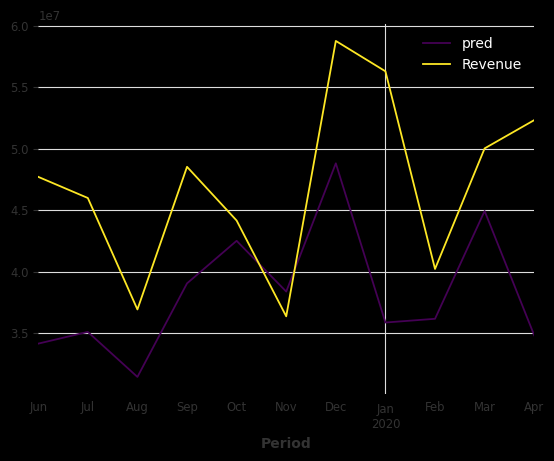

In [204]:
combined_df.dropna(inplace=True)
X = combined_df.drop(columns=['Revenue'])
y = combined_df['Revenue']
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
X_train = X.iloc[:-11]
y_train = y[:-11]
X_test = X.iloc[-11:]
y_test = y[-11:]
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("mape:", mape(y_test, y_pred))
print("rmse: ", rmse(y_test, y_pred))
testdf = combined_df[['Revenue']].iloc[-11:]
testdf['pred'] = y_pred
testdf[['pred','Revenue']].plot(colormap='viridis')

best params:  {'criterion': 'friedman_mse', 'max_depth': 9, 'n_estimators': 50, 'n_jobs': -1, 'oob_score': True}
mape: 0.12643599999474806
rmse:  6907918.675322808
r2 score:  0.015545295019886107


<Axes: xlabel='Period'>

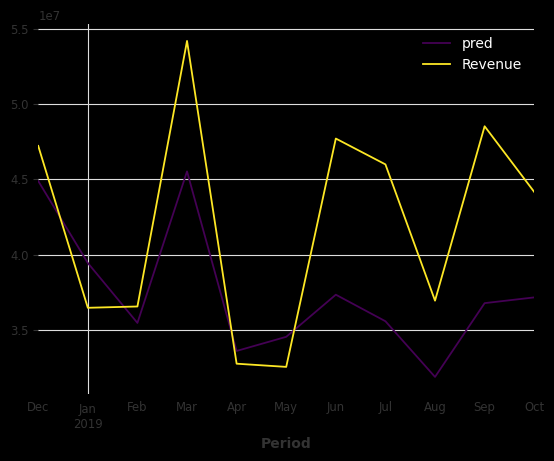

In [188]:
seas_df.dropna(inplace=True)
X = seas_df.drop(columns=['Revenue'])
y = seas_df['Revenue']
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
X_train = X.iloc[:-11]
y_train = y[:-11]
X_test = X.iloc[-11:]
y_test = y[-11:]
model = RandomForestRegressor()
params={
    "n_estimators":[50,80,100,120],
    "criterion": ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
    "max_depth": [5,7,9,11],
    "oob_score" : [True],
    "n_jobs": [-1],
}
gmodel = GridSearchCV(estimator=model, scoring='neg_root_mean_squared_error', cv=5, param_grid=params, n_jobs=-1)
gmodel.fit(X_train, y_train)
y_pred = gmodel.best_estimator_.predict(X_test)
print("best params: ",gmodel.best_params_)
print("mape:", mape(y_test, y_pred))
print("rmse: ", rmse(y_test, y_pred))
print("r2 score: ",r2_score(y_test, y_pred))
testdf = seas_df[['Revenue']].iloc[-11:]
testdf['pred'] = y_pred
testdf[['pred','Revenue']].plot(colormap='viridis')

In [44]:
X.columns

Index(['Revenue_lag_1', 'Revenue_lag_2', 'Revenue_lag_12',
       'Revenue_window_3_mean', 'Revenue_window_3_std', 'Revenue_window_3_max',
       'Revenue_expanding_mean', 'Revenue_expanding_std', 'Trend', 'Seas',
       'Resid'],
      dtype='object')

In [49]:
df.rename(columns={'Revenue':'Value'},inplace=True)

Forecasted Values: 11
mape: 0.1826932794401623
rmse-  8689039.99433505
r2_score-  -2.847183268193932


<Axes: xlabel='Period'>

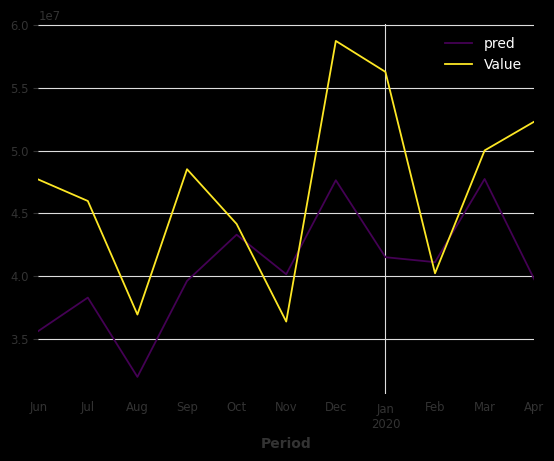

In [245]:
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import Normalizer
class LaggedFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Value',p=[1,7,30,12]):
        self.var = var
        self.p = p
    def fit(self,X,y=None):
        return self
    def transform(self, X):
        lag_trans = LagFeatures(variables=[self.var],periods=self.p)
        df_lagged = lag_trans.fit_transform(X)
        df_lagged.drop(columns=[self.var],inplace=True)
        return df_lagged
    
class RolledFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Value',w=3):
        self.var = var
        self.w = w
    def fit(self,X,y=None):
        return self
    def transform(self, X):
        roll_trans = WindowFeatures(variables=[self.var],window=self.w,functions=['mean', 'std', 'max','min'])
        df_roll = roll_trans.fit_transform(X)
        df_roll.drop(columns=[self.var],inplace=True)
        return df_roll
    
class ExpandFeatures(BaseEstimator,TransformerMixin):
    def __init__(self,var='Value'):
        self.var = var
    def fit(self,X,y=None):
        return self
    def transform(self, X):
        expan_trans = ExpandingWindowFeatures(variables=[self.var],functions=['mean', 'std'])
        df_expand = expan_trans.fit_transform(X)
        df_expand.drop(columns=[self.var],inplace=True)
        return df_expand
    
features = FeatureUnion([
        ('lag',LaggedFeatures(p=[1,2,6,9,12,24])),
        ('roll',RolledFeatures(w=[3,6,12,24])),
        ('exp',ExpandFeatures())
    ])

class Forcaster(BaseEstimator,RegressorMixin):
    def __init__(self,model,lag=13):
        self.model = model
        self.lag = lag
    def fit(self,X,y):
        self.model.fit(X,y)
        self.last = y[-self.lag:]
        return self
    def predict(self, X):
        return self.model.predict(X)
    def forecast(self,pipeline,y,steps):
        forecasts = []
        freq = pd.infer_freq(y.index) or y.index.freqstr
        future_indices = pd.date_range(start=y.index[-1], periods=steps + 2, freq=freq)[1:]
        dummy =0
        prev = future_indices[0]
        new_entry = pd.Series(dummy, index=[future_indices[0]],name='Value')
        y = pd.concat([y, new_entry])
        for next_timestamp in future_indices[1:]:
            last_features = pipeline.named_steps['features'].transform(y)
            next_value = pipeline.named_steps['model'].predict(last_features[-1].reshape(1,-1))
            forecasts.append(next_value[0])
            y.loc[prev, "Value"]= next_value
            new_entry = pd.Series(dummy, index=[next_timestamp],name='Value')
            y = pd.concat([y, new_entry])
            prev= next_timestamp
        return forecasts
pipeline = Pipeline([
    ('features', features),
    ('model', Forcaster(model=RandomForestRegressor(random_state=42,criterion='squared_error',max_depth=5,n_estimators= 50,n_jobs=-1,oob_score=True),lag=13))
])
step=11
tdf = df.iloc[:-step].copy()
pipeline.fit(tdf,tdf['Value'])
forecasted_values = pipeline.named_steps['model'].forecast(pipeline=pipeline,steps=step,y=tdf)
print("Forecasted Values:", len(forecasted_values))
print("mape:", mape(forecasted_values,df['Value'].iloc[-step:]))
print("rmse- ",rmse(forecasted_values,df['Value'].iloc[-step:]))
print("r2_score- ",r2_score(forecasted_values,df['Value'].iloc[-step:]))
tedf= df.iloc[-step:].copy()
tedf['pred'] = forecasted_values
tedf[['pred','Value']].plot(colormap='viridis')
